# 2-Triangle on Real Registration Slices

The previous notebooks (01-05) used synthetic folds: the 7x7 bowtie and `test_cases` fold-library entries. This one runs the best 2-triangle SLSQP on **real slices** pulled through the Laplacian registration pipeline (`test_cases.load_slice`), and compares it to CD-SLSQP and FD-SLSQP on the same fields.

Two slices, both downsampled with `scale_factor=0.08` to keep SLSQP tractable (~900 pixels / ~1800 variables):

- **slice 90** (`02a`) - initial CD Jdet has `neg=0` (central-diff is completely blind), yet 2-triangle flags 35 folded cells. Real-data instance of the bowtie/shoelace-artifact failure mode.
- **slice 350** (`02c`) - same pattern, `neg_CD=0` vs `neg_TR=12`.

This is the most direct evidence that switching from central-difference to a geometric fold check matters on real registration output, not just synthetic constructions.

In [1]:
import os, sys, time
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, NonlinearConstraint
from scipy.sparse import csr_matrix

from dvfopt import DEFAULT_PARAMS, jacobian_det2D
from dvfopt.jacobian import triangle_sign_areas2D
from dvfopt.jacobian.numpy_jdet import _numpy_jdet_2d
from dvfopt.jacobian.triangle_sign import _triangle_areas_2d
from dvfopt.jacobian.intersection import has_quad_self_intersections, _quads_intersect
from dvfopt.core.objective import objective_euc

from test_cases._builders import load_slice

THRESHOLD = DEFAULT_PARAMS['threshold']
MPOINTS = os.path.abspath('../../data/corrected_correspondences_count_touching/mpoints.npy')
FPOINTS = os.path.abspath('../../data/corrected_correspondences_count_touching/fpoints.npy')
print(f'threshold = {THRESHOLD}')
print(f'mpoints exists: {os.path.exists(MPOINTS)}')
print(f'fpoints exists: {os.path.exists(FPOINTS)}')

threshold = 0.01
mpoints exists: True
fpoints exists: True


In [2]:
def _forward_jdet_2d(dy, dx):
    ddx_dx = dx[:-1, 1:]  - dx[:-1, :-1]
    ddy_dy = dy[1:,  :-1] - dy[:-1, :-1]
    ddx_dy = dx[1:,  :-1] - dx[:-1, :-1]
    ddy_dx = dy[:-1, 1:]  - dy[:-1, :-1]
    return (1 + ddx_dx) * (1 + ddy_dy) - ddx_dy * ddy_dx

def measure(phi):
    jd = np.squeeze(jacobian_det2D(phi))
    fd = _forward_jdet_2d(phi[0], phi[1])
    tri = triangle_sign_areas2D(phi)
    return dict(
        jd=jd, fd=fd, tri=tri,
        n_cd=int((jd <= 0).sum()),
        n_fd=int((fd <= 0).sum()),
        n_tr=int((tri <= 0).sum()),
        min_cd=float(jd.min()),
        min_fd=float(fd.min()),
        min_tr=float(tri.min()),
    )

def list_intersecting_quads(phi):
    dy, dx = phi[0], phi[1]
    H, W = dy.shape
    nr, nc = H - 1, W - 1
    if nr <= 0 or nc <= 0:
        return []
    rows = np.arange(H, dtype=float)[:, None]
    cols = np.arange(W, dtype=float)[None, :]
    Y = rows + dy; X = cols + dx
    y_tl, x_tl = Y[:-1, :-1], X[:-1, :-1]
    y_tr, x_tr = Y[:-1, 1:],  X[:-1, 1:]
    y_br, x_br = Y[1:,  1:],  X[1:,  1:]
    y_bl, x_bl = Y[1:,  :-1], X[1:,  :-1]
    ymin = np.minimum(np.minimum(y_tl, y_tr), np.minimum(y_bl, y_br)).ravel()
    ymax = np.maximum(np.maximum(y_tl, y_tr), np.maximum(y_bl, y_br)).ravel()
    xmin = np.minimum(np.minimum(x_tl, x_tr), np.minimum(x_bl, x_br)).ravel()
    xmax = np.maximum(np.maximum(x_tl, x_tr), np.maximum(x_bl, x_br)).ravel()
    corners = np.stack([
        np.stack([y_tl.ravel(), x_tl.ravel()], axis=1),
        np.stack([y_tr.ravel(), x_tr.ravel()], axis=1),
        np.stack([y_br.ravel(), x_br.ravel()], axis=1),
        np.stack([y_bl.ravel(), x_bl.ravel()], axis=1),
    ], axis=1)
    n_quads = nr * nc
    pairs = []
    for i in range(n_quads):
        ri, ci = divmod(i, nc)
        for j in range(i + 1, n_quads):
            rj, cj = divmod(j, nc)
            if abs(ri - rj) <= 1 and abs(ci - cj) <= 1: continue
            if (ymin[i] > ymax[j] or ymax[i] < ymin[j]
                    or xmin[i] > xmax[j] or xmax[i] < xmin[j]): continue
            if _quads_intersect(corners[i], corners[j]):
                pairs.append(((ri, ci), (rj, cj)))
    return pairs

In [3]:
# Analytical Jacobian of the 2-triangle constraint.
def triangle_sign_constraint_jac_2d(dy, dx):
    H_, W_ = dy.shape
    nr, nc = H_ - 1, W_ - 1
    N = H_ * W_
    ref_y, ref_x = np.mgrid[:H_, :W_]
    X = ref_x + dx; Y = ref_y + dy
    TLx, TLy = X[:-1, :-1], Y[:-1, :-1]
    TRx, TRy = X[:-1, 1:],  Y[:-1, 1:]
    BLx, BLy = X[1:,  :-1], Y[1:,  :-1]
    BRx, BRy = X[1:,  1:],  Y[1:,  1:]
    cy_grid, cx_grid = np.mgrid[:nr, :nc]
    cy = cy_grid.ravel(); cx = cx_grid.ravel()
    def dx_idx(py, px): return py * W_ + px
    def dy_idx(py, px): return N + py * W_ + px
    n_cells = nr * nc
    T1_rows = np.tile(np.arange(n_cells), 6)
    T1_cols = np.concatenate([
        dx_idx(cy, cx + 1), dy_idx(cy, cx + 1),
        dx_idx(cy + 1, cx), dy_idx(cy + 1, cx),
        dx_idx(cy + 1, cx + 1), dy_idx(cy + 1, cx + 1),
    ])
    T1_vals = np.concatenate([
        0.5 * (BRy - BLy).ravel(), 0.5 * (BLx - BRx).ravel(),
        0.5 * (TRy - BRy).ravel(), 0.5 * (BRx - TRx).ravel(),
        0.5 * (BLy - TRy).ravel(), 0.5 * (TRx - BLx).ravel(),
    ])
    T2_rows = np.tile(np.arange(n_cells) + n_cells, 6)
    T2_cols = np.concatenate([
        dx_idx(cy, cx),     dy_idx(cy, cx),
        dx_idx(cy + 1, cx), dy_idx(cy + 1, cx),
        dx_idx(cy, cx + 1), dy_idx(cy, cx + 1),
    ])
    T2_vals = np.concatenate([
        0.5 * (TRy - BLy).ravel(), 0.5 * (BLx - TRx).ravel(),
        0.5 * (TLy - TRy).ravel(), 0.5 * (TRx - TLx).ravel(),
        0.5 * (BLy - TLy).ravel(), 0.5 * (TLx - BLx).ravel(),
    ])
    rows = np.concatenate([T1_rows, T2_rows])
    cols = np.concatenate([T1_cols, T2_cols])
    vals = np.concatenate([T1_vals, T2_vals])
    return csr_matrix((vals, (rows, cols)), shape=(2 * n_cells, 2 * N))

In [4]:
def _run_slsqp(phi_init, fun, jac=None, threshold=THRESHOLD, max_iter=500,
                warm_start=False, noise_scale=0.01):
    _, H_, W_ = phi_init.shape
    pixels = H_ * W_
    def unpack(z):
        dx_ = z[:pixels].reshape(H_, W_)
        dy_ = z[pixels:].reshape(H_, W_)
        return dy_, dx_
    z0 = np.concatenate([phi_init[1].flatten(), phi_init[0].flatten()])
    z0_init = z0.copy()
    nl_kwargs = dict(lb=threshold, ub=np.inf)
    if jac is not None:
        nl_kwargs['jac'] = lambda z: jac(*unpack(z))
    t0 = time.time()
    res = minimize(lambda z: objective_euc(z, z0_init), z0,
                   jac=True, method='SLSQP',
                   constraints=[NonlinearConstraint(lambda z: fun(*unpack(z)), **nl_kwargs)],
                   options={'maxiter': max_iter, 'disp': False})
    total_nit = res.nit; total_time = time.time() - t0
    if warm_start and not res.success and res.status == 8:
        rng = np.random.default_rng(123)
        z_warm = res.x + rng.normal(scale=noise_scale, size=res.x.shape)
        t1 = time.time()
        res = minimize(lambda z: objective_euc(z, z0_init), z_warm,
                       jac=True, method='SLSQP',
                       constraints=[NonlinearConstraint(lambda z: fun(*unpack(z)), **nl_kwargs)],
                       options={'maxiter': 2000, 'ftol': 1e-10, 'disp': False})
        total_nit += res.nit; total_time += time.time() - t1
    dy_o, dx_o = unpack(res.x)
    phi_out = np.stack([dy_o, dx_o])
    m = measure(phi_out)
    m.update(phi=phi_out, nit=total_nit, time=total_time,
             success=bool(res.success), status=int(res.status),
             message=str(res.message),
             l2=float(np.linalg.norm(phi_out - phi_init)))
    return m

def run_cd(phi_init, **kw):
    return _run_slsqp(phi_init, fun=lambda dy, dx: _numpy_jdet_2d(dy, dx).flatten(), **kw)

def run_fd(phi_init, **kw):
    return _run_slsqp(phi_init, fun=lambda dy, dx: _forward_jdet_2d(dy, dx).flatten(), **kw)

def run_2tri(phi_init, **kw):
    def tri_flat(dy, dx):
        T1, T2 = _triangle_areas_2d(dy, dx)
        return np.concatenate([T1.flatten(), T2.flatten()])
    return _run_slsqp(phi_init, fun=tri_flat,
                       jac=triangle_sign_constraint_jac_2d, warm_start=True, **kw)

## Load slices and report initial state

Two real slices at `scale_factor=0.08` (~25x36, ~900 pixels each). Reporting each measure's initial fold count plus the global quad-intersection count.

In [5]:
SLICES = [
    ('slice_090_s08',  90, 0.08),
    ('slice_350_s08', 350, 0.08),
]

cases = {}
for name, idx, sf in SLICES:
    deformation, *_ = load_slice(idx, sf, mpoints_path=MPOINTS, fpoints_path=FPOINTS)
    phi = np.stack([deformation[1, 0], deformation[2, 0]])
    m0 = measure(phi)
    qi0 = list_intersecting_quads(phi)
    cases[name] = dict(phi=phi, m0=m0, qi0=qi0, slice_idx=idx, sf=sf)
    print(f'{name:<18s}  shape={phi[0].shape}  pix={phi[0].size}  '
          f'n_cd={m0["n_cd"]:>3d}  n_fd={m0["n_fd"]:>3d}  n_tr={m0["n_tr"]:>3d}  '
          f'QI={len(qi0):>4d}  min_tr={m0["min_tr"]:+.3f}')

Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A


slice_090_s08       shape=(25, 36)  pix=900  n_cd=  0  n_fd= 18  n_tr= 35  QI=  50  min_tr=-1.501


Building data for Laplacian Sparse Matrix A (optimized)
Creating Laplacian Sparse Matrix A


slice_350_s08       shape=(25, 36)  pix=900  n_cd=  0  n_fd=  9  n_tr= 12  QI=  10  min_tr=-1.000


## Run each constraint formulation on each slice

CD-SLSQP, FD-SLSQP, best-2tri SLSQP - same three runners as [04_constraint-comparison.ipynb](04_constraint-comparison.ipynb), applied here to real registration output. Each slice is ~900 pixels -> ~1800 variables, a manageable problem size for SLSQP.

In [6]:
results = {}
for name, case in cases.items():
    phi = case['phi']
    print(f'>>> {name}')
    results[name] = dict(
        phi_init=phi, m0=case['m0'], qi0=case['qi0'],
        cd=run_cd(phi), fd=run_fd(phi), tri=run_2tri(phi),
    )
    for key in ('cd', 'fd', 'tri'):
        r = results[name][key]
        print(f"    {key:<5s}  nit={r['nit']:>4d}  time={r['time']:>6.2f}s  success={str(r['success']):<5s}  "
              f"neg_CD={r['n_cd']:>3d}  neg_TR={r['n_tr']:>3d}  L2={r['l2']:.3f}")
    # global intersections on the tri run
    qi_tri = list_intersecting_quads(results[name]['tri']['phi'])
    results[name]['qi_tri'] = qi_tri
    print(f'    post-2tri QI pairs = {len(qi_tri)}')

>>> slice_090_s08


    cd     nit=   2  time=  3.68s  success=True   neg_CD=  0  neg_TR= 35  L2=0.017
    fd     nit=   6  time= 10.46s  success=True   neg_CD=  0  neg_TR=  6  L2=0.696
    tri    nit=  30  time= 80.73s  success=True   neg_CD=  0  neg_TR=  0  L2=1.102
    post-2tri QI pairs = 0
>>> slice_350_s08


    cd     nit=   2  time=  3.65s  success=True   neg_CD=  0  neg_TR= 12  L2=0.010
    fd     nit=   5  time=  8.88s  success=True   neg_CD=  0  neg_TR=  3  L2=0.695
    tri    nit=  19  time= 58.11s  success=True   neg_CD=  0  neg_TR=  0  L2=1.227
    post-2tri QI pairs = 0


## Cross-case summary

Init TR = how many folded cells the 2-triangle check finds before any correction. For each variant: `nit`, final `neg_TR`, and L2 distortion from the original field.

In [7]:
hdr = (f"{'case':<18s}  {'init TR':>8s}  {'init QI':>8s}  "
        + '  '.join(f"{k:>6s}" for k in ('CD nit', 'CD TR', 'CD L2',
                                          'FD nit', 'FD TR', 'FD L2',
                                          'TR nit', 'TR TR', 'TR L2', 'TR QI')))
print(hdr)
print('-' * len(hdr))
for name, r in results.items():
    line = f"{name:<18s}  {r['m0']['n_tr']:>8d}  {len(r['qi0']):>8d}"
    for key in ('cd', 'fd'):
        m = r[key]
        line += f"  {m['nit']:>6d}  {m['n_tr']:>6d}  {m['l2']:>6.3f}"
    m = r['tri']
    line += f"  {m['nit']:>6d}  {m['n_tr']:>6d}  {m['l2']:>6.3f}  {len(r['qi_tri']):>6d}"
    print(line)

case                 init TR   init QI  CD nit   CD TR   CD L2  FD nit   FD TR   FD L2  TR nit   TR TR   TR L2   TR QI
----------------------------------------------------------------------------------------------------------------------
slice_090_s08             35        50       2      35   0.017       6       6   0.696      30       0   1.102       0
slice_350_s08             12        10       2      12   0.010       5       3   0.695      19       0   1.227       0


## Warped-grid visualization per slice

Row per slice, 4 columns: initial, (A) CD-SLSQP, (B) FD-SLSQP, (C) best-2tri. Folded cells under the 2-triangle check outlined in dark blue. Row 2 below is the `min(T1, T2)` heatmap.

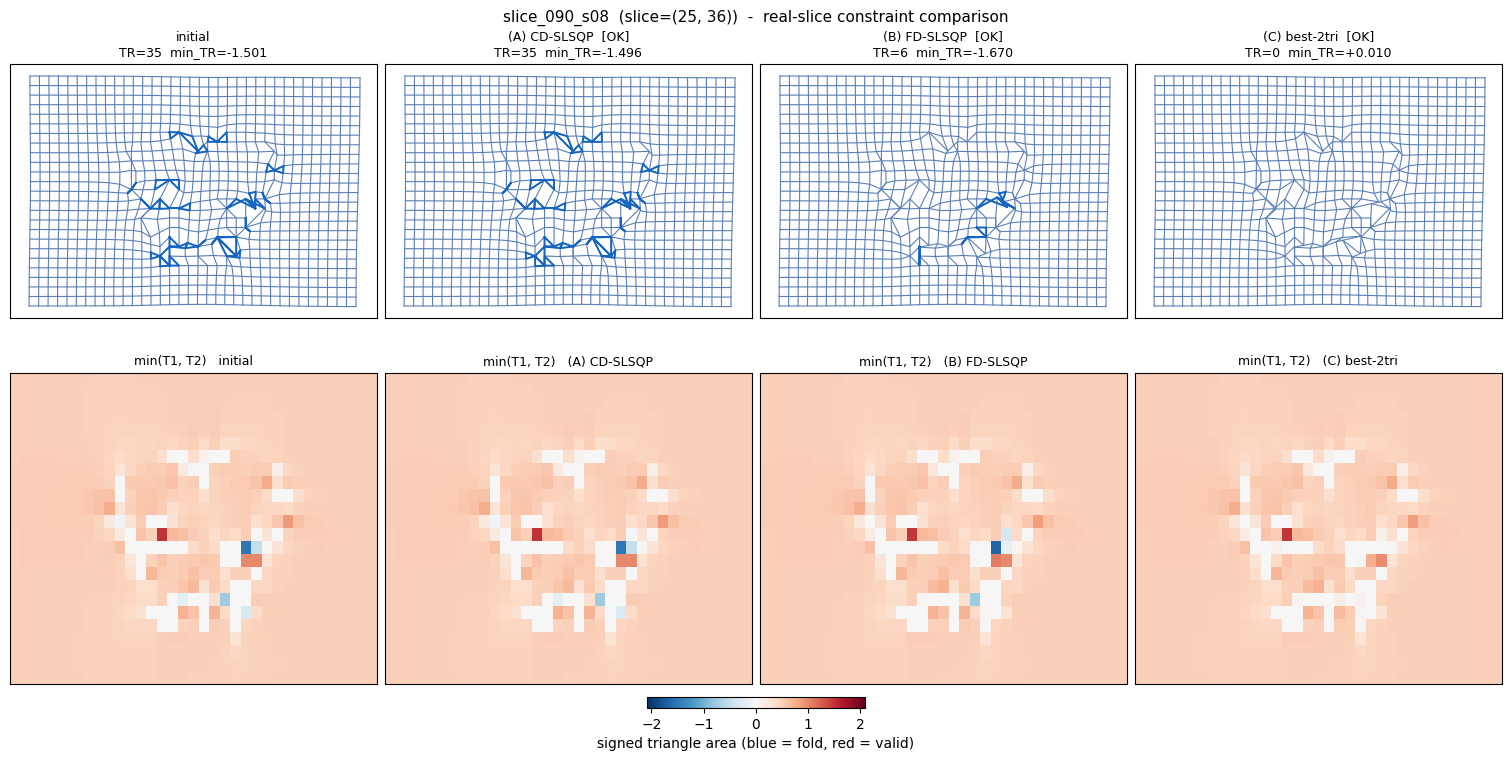

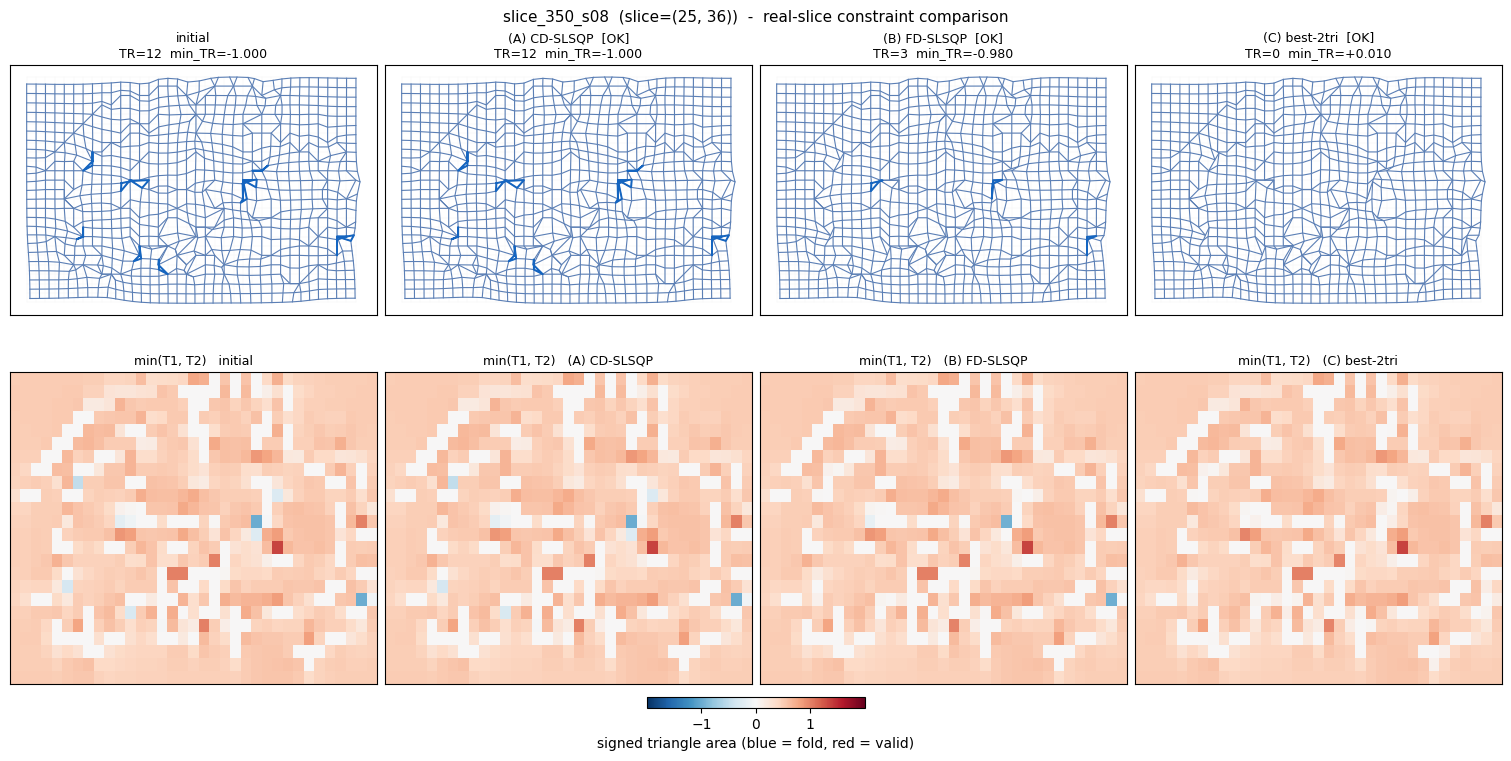

In [8]:
def plot_warped_grid(ax, phi, title, highlight_folds=True):
    dy = phi[0]; dx = phi[1]
    Hh, Ww = dy.shape
    yy, xx = np.mgrid[:Hh, :Ww]
    gx = xx + dx; gy = yy + dy
    for i in range(Hh):
        ax.plot(xx[i], yy[i], color='#f4f4f4', lw=0.3)
    for j in range(Ww):
        ax.plot(xx[:, j], yy[:, j], color='#f4f4f4', lw=0.3)
    for i in range(Hh):
        ax.plot(gx[i], gy[i], color='#5b7fb5', lw=0.8)
    for j in range(Ww):
        ax.plot(gx[:, j], gy[:, j], color='#5b7fb5', lw=0.8)
    if highlight_folds:
        tri = triangle_sign_areas2D(phi)
        bad = np.argwhere(tri.min(axis=0) <= 0)
        for (cy, cx) in bad:
            poly_x = [gx[cy, cx], gx[cy, cx+1], gx[cy+1, cx+1], gx[cy+1, cx], gx[cy, cx]]
            poly_y = [gy[cy, cx], gy[cy, cx+1], gy[cy+1, cx+1], gy[cy+1, cx], gy[cy, cx]]
            ax.plot(poly_x, poly_y, color='#1565c0', lw=1.4)
    ax.set_aspect('equal'); ax.invert_yaxis()
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

NL = chr(10)

for name, r in results.items():
    variants = [
        ('initial',       r['phi_init'], r['m0'],   None),
        ('(A) CD-SLSQP',  r['cd']['phi'], r['cd'],   r['cd']),
        ('(B) FD-SLSQP',  r['fd']['phi'], r['fd'],   r['fd']),
        ('(C) best-2tri', r['tri']['phi'], r['tri'], r['tri']),
    ]
    vmax_tri = max(abs(m['tri']).max() for _, _, m, _ in variants)

    fig, axes = plt.subplots(2, 4, figsize=(15, 7.5), layout='constrained')
    for k, (label, phi, m, res) in enumerate(variants):
        if res is None:
            line1 = label
        else:
            tag = 'OK' if res['success'] else 'FAIL'
            line1 = f'{label}  [{tag}]'
        line2 = f"TR={m['n_tr']}  min_TR={m['min_tr']:+.3f}"
        plot_warped_grid(axes[0, k], phi, line1 + NL + line2)
        tri_min = m['tri'].min(axis=0)
        im = axes[1, k].imshow(tri_min, cmap='RdBu_r', vmin=-vmax_tri, vmax=vmax_tri, aspect='auto')
        axes[1, k].set_title(f'min(T1, T2)   {label}', fontsize=9)
        axes[1, k].set_xticks([]); axes[1, k].set_yticks([])
    cbar = fig.colorbar(im, ax=axes[1, :], orientation='horizontal',
                         fraction=0.035, pad=0.04, shrink=0.55)
    cbar.set_label('signed triangle area (blue = fold, red = valid)')
    plt.suptitle(f'{name}  (slice={r["phi_init"][0].shape})  -  real-slice constraint comparison',
                  fontsize=11)
    plt.show()

## Disagreement overlay - cells where CD / FD passed but 2-tri still flags

Same overlay idea as [04_constraint-comparison.ipynb](04_constraint-comparison.ipynb). On these real slices the effect is severe: CD converges with `success=True` and leaves **most of the initial folds in place** because its own stencil doesn't see them.

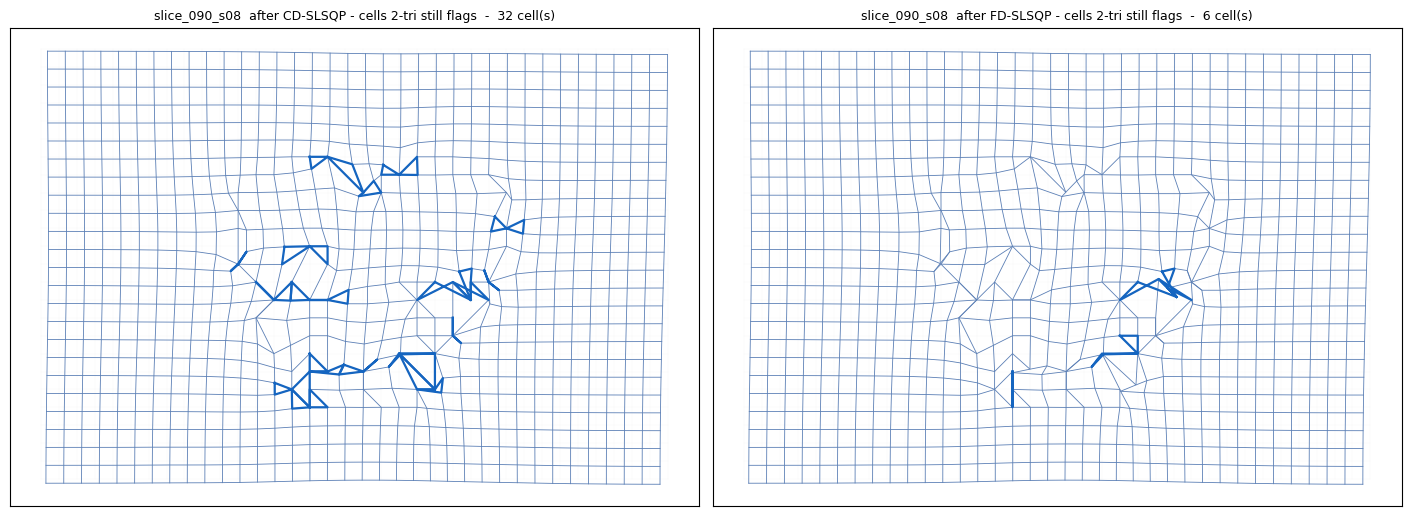

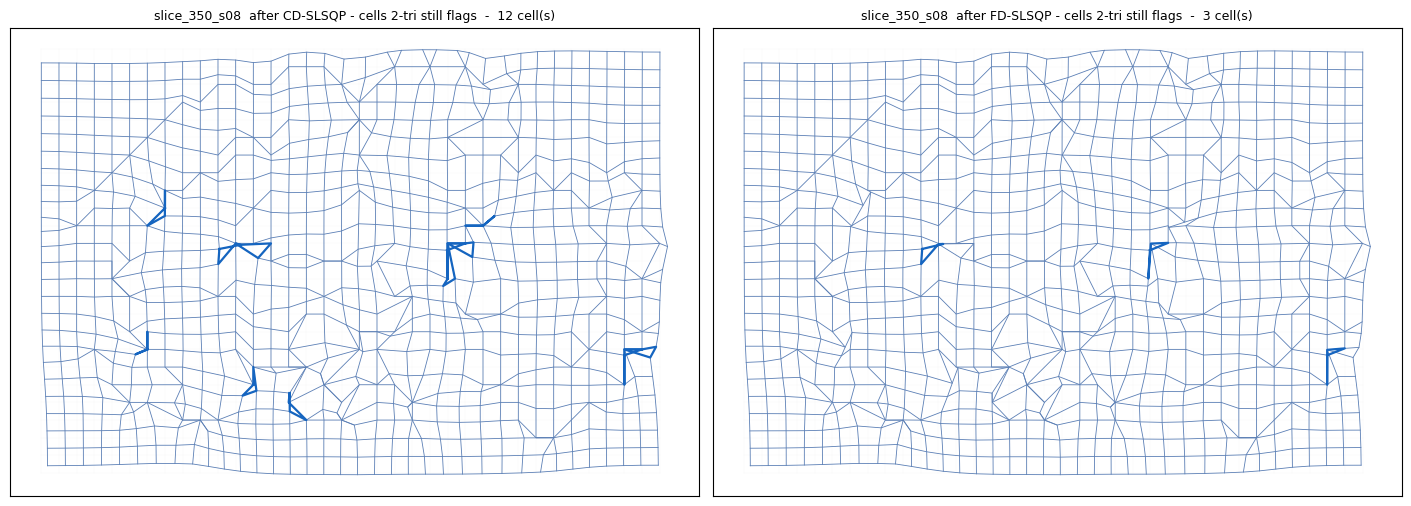

In [9]:
def plot_disagreement(name, r):
    phi_cd = r['cd']['phi'];  phi_fd = r['fd']['phi']
    cd_tri_min = r['cd']['tri'].min(axis=0)
    fd_tri_min = r['fd']['tri'].min(axis=0)
    cd_bad = (cd_tri_min <= 0); fd_bad = (fd_tri_min <= 0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), layout='constrained')
    for ax, phi, bad_mask, title in [
        (axes[0], phi_cd, cd_bad, f'{name}  after CD-SLSQP - cells 2-tri still flags'),
        (axes[1], phi_fd, fd_bad, f'{name}  after FD-SLSQP - cells 2-tri still flags'),
    ]:
        dy, dx = phi[0], phi[1]
        Hh, Ww = dy.shape
        yy, xx = np.mgrid[:Hh, :Ww]
        gx = xx + dx; gy = yy + dy
        for i in range(Hh):
            ax.plot(xx[i], yy[i], color='#f8f8f8', lw=0.3)
        for j in range(Ww):
            ax.plot(xx[:, j], yy[:, j], color='#f8f8f8', lw=0.3)
        for i in range(Hh):
            ax.plot(gx[i], gy[i], color='#5b7fb5', lw=0.6)
        for j in range(Ww):
            ax.plot(gx[:, j], gy[:, j], color='#5b7fb5', lw=0.6)
        for (cy, cx) in np.argwhere(bad_mask):
            poly_x = [gx[cy, cx], gx[cy, cx+1], gx[cy+1, cx+1], gx[cy+1, cx], gx[cy, cx]]
            poly_y = [gy[cy, cx], gy[cy, cx+1], gy[cy+1, cx+1], gy[cy+1, cx], gy[cy, cx]]
            ax.plot(poly_x, poly_y, color='#1565c0', lw=1.6)
        ax.set_aspect('equal'); ax.invert_yaxis()
        n = int(bad_mask.sum())
        ax.set_title(f'{title}  -  {n} cell(s)', fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
    plt.show()

for name, r in results.items():
    plot_disagreement(name, r)

## Summary

Running on real slices produced by the Laplacian registration pipeline:

- **Central-difference Jdet is blind** on these slices. `neg_CD=0` initially even though the 2-triangle check sees 12-35 folded cells. CD-SLSQP converges `success=True` at `nit=1` and does nothing - there's no work to do from its point of view.
- **Forward-difference** is partially useful: it detects more folds than CD (still misses some) and makes progress but leaves residuals.
- **Best 2-triangle (analytical + warm-start)** converges to `neg_TR=0` and (on these cases) drives global quad-intersection count `QI` to 0 as well. This is the configuration needed if downstream code evaluates validity with a geometric fold check.

Implication for the pipeline: if you're using `iterative_serial` or a similar SLSQP-based corrector with the default central-diff Jacobian-determinant constraint, you may be accepting fields that are geometrically folded. Switching the constraint to the 2-triangle signed-area check (or the stricter 4-triangle check in `dvfopt.jacobian.triangle_det2D`) plugs the gap.

Next step candidates: promote `triangle_sign_constraint_jac_2d` from these notebooks into [dvfopt/jacobian/triangle_sign.py](../../dvfopt/jacobian/triangle_sign.py) next to `triangle_sign_constraint`, and wire an `enforce_triangles_sign=True` option into `iterative_serial` analogous to the existing `enforce_shoelace` / `enforce_triangles` flags.